# Medical Cost Prediction with different ML tools

## Kiki Beumer & Yudita Joseph

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBRFRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
dataset = pd.read_csv("medical_costs.csv")

dataset.shape

(10000, 7)

In [3]:
dataset.head()

,Age,Sex,BMI,Children,Smoker,Region,Medical Cost
0,58,male,15.6,2,yes,northwest,17907.54
1,24,male,29.8,0,yes,northeast,16312.64
2,50,male,29.0,5,no,northwest,6819.21
3,35,male,34.0,1,no,southeast,5247.87
4,31,female,17.6,3,yes,southeast,17525.49


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           10000 non-null  int64  
 1   Sex           10000 non-null  object 
 2   BMI           10000 non-null  float64
 3   Children      10000 non-null  int64  
 4   Smoker        10000 non-null  object 
 5   Region        10000 non-null  object 
 6   Medical Cost  10000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 547.0+ KB


In [5]:
dataset.describe()


,Age,BMI,Children,Medical Cost
count,10000.000000,10000.00000,10000.000000,10000.000000
mean,41.678400,27.40301,2.501700,11898.932216
std,13.807724,7.22896,1.701672,6073.875834
min,18.000000,15.00000,0.000000,3617.090000
25%,30.000000,21.10000,1.000000,5909.925000
50%,42.000000,27.40000,2.000000,7957.430000
75%,54.000000,33.70000,4.000000,17931.962500
max,65.000000,40.00000,5.000000,20268.210000


In [6]:
dataset.isnull().sum()


Age             0
Sex             0
BMI             0
Children        0
Smoker          0
Region          0
Medical Cost    0
dtype: int64

In [7]:
dataset['Smoker'].value_counts()


Smoker
no     5008
yes    4992
Name: count, dtype: int64

In [8]:
dataset['Region'].value_counts()


Region
southwest    2521
northeast    2514
northwest    2486
southeast    2479
Name: count, dtype: int64

In [9]:
dataset['Sex'].value_counts()


Sex
female    5034
male      4966
Name: count, dtype: int64

In [10]:
cat = []
num = []

for col in dataset.columns:
    if dataset[col].dtypes == 'object':
        cat.append(col)
    elif dataset[col].dtypes in ['int64', 'float64']:
        num.append(col)

print(cat)
print(num)

['Sex', 'Smoker', 'Region']
['Age', 'BMI', 'Children', 'Medical Cost']


In [11]:
# distribution for num features
def numFeatDistribution(df, num_cols):

    if len(num_cols) == 0:
        return
    
    for col in num_cols:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, bins=20)
        plt.title(f"{col} Distribution")
        plt.xlabel(f"{col}")
        plt.ylabel("Frequency")
        plt.show()

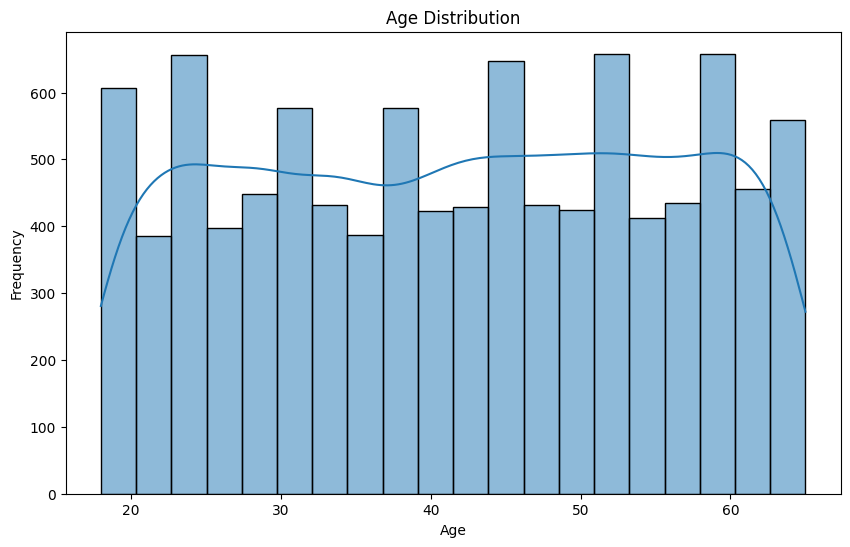

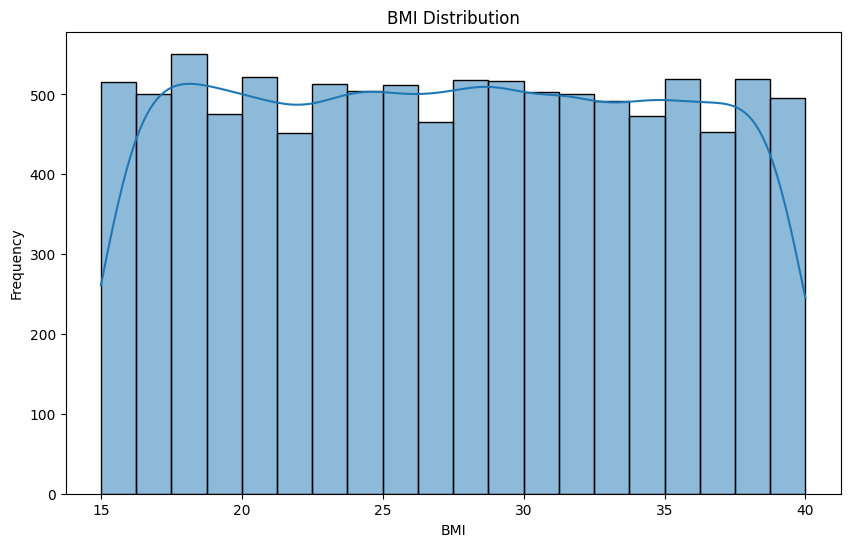

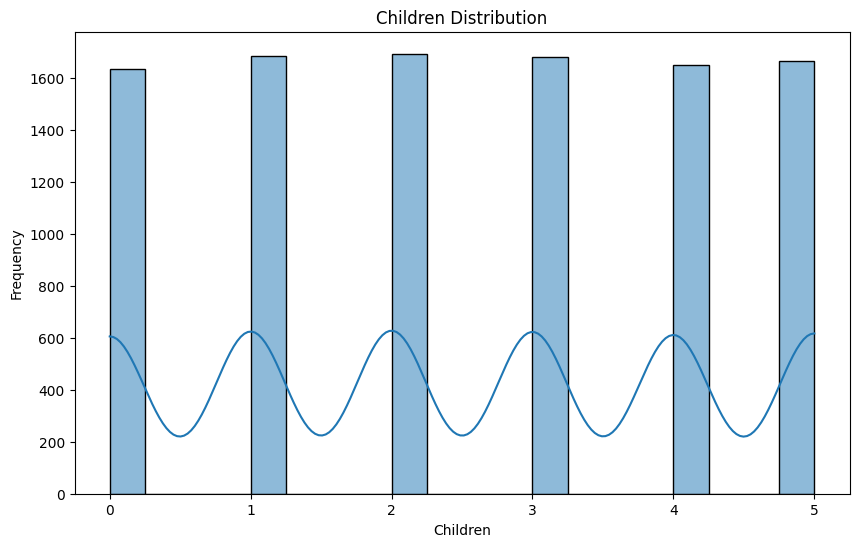

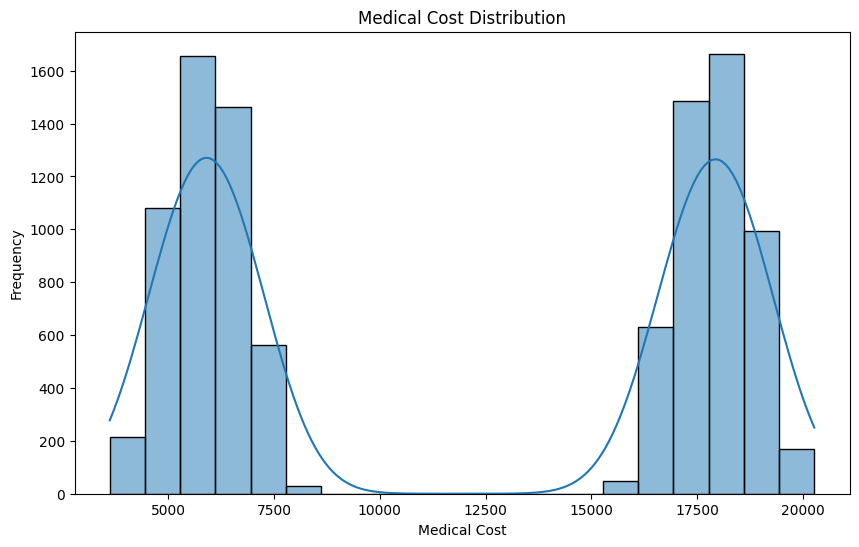

In [12]:
numFeatDistribution(dataset, num)


In [13]:
# distribution for cat features
def catFeatureDistribution(df, cat_feats):

    if len(cat_feats) == 0:
        return
    
    for col in cat_feats:
        plt.figure(figsize=(10, 6))
        sns.countplot(x=col, data=df)
        plt.title(f"{col} Distribution")
        plt.xlabel(f'{col}')
        plt.ylabel("Frequency")
        plt.show()

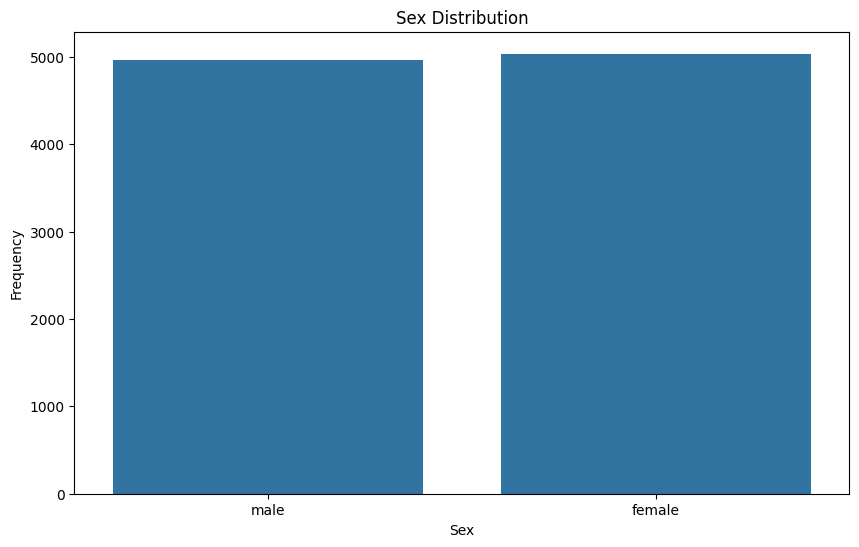

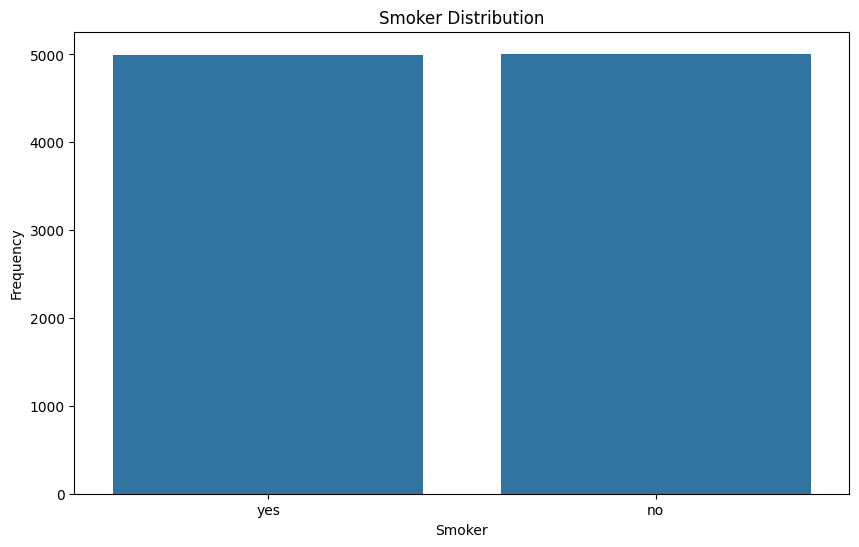

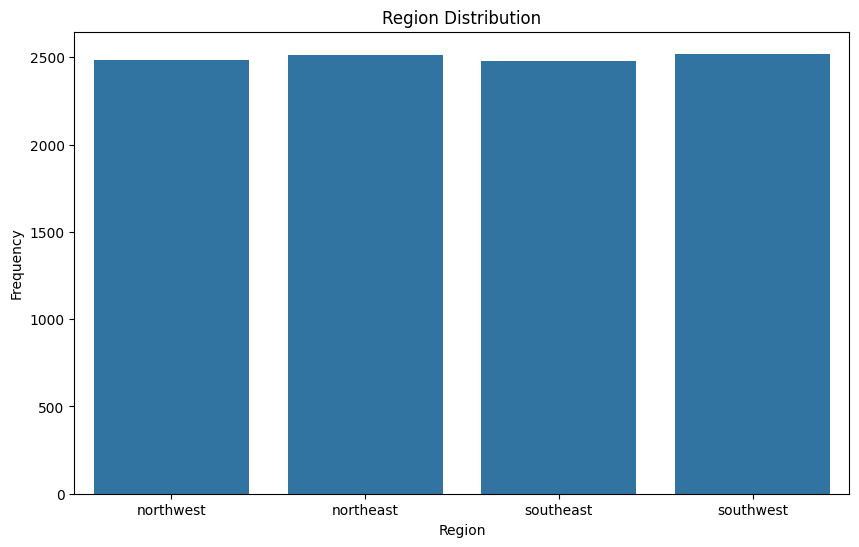

In [14]:
catFeatureDistribution(dataset, cat)


In [15]:
# Bivariate Analysis [Numerical vs Numerical[Medical Cost]]
def plotNumvsMedicalCost(df, num_feats):

    if len(num_feats) == 0:
        return
    
    for col in num_feats:
        if col != 'Medical Cost':
            plt.figure(figsize=(10, 6))
            sns.boxplot(x=col, y='Medical Cost', data=df)
            plt.title(f"{col.capitalize()} vs Medical Cost")
            plt.xlabel(f"Number of {col.capitalize()}")
            plt.ylabel("Medical Cost")
            plt.show()
        else:
            return

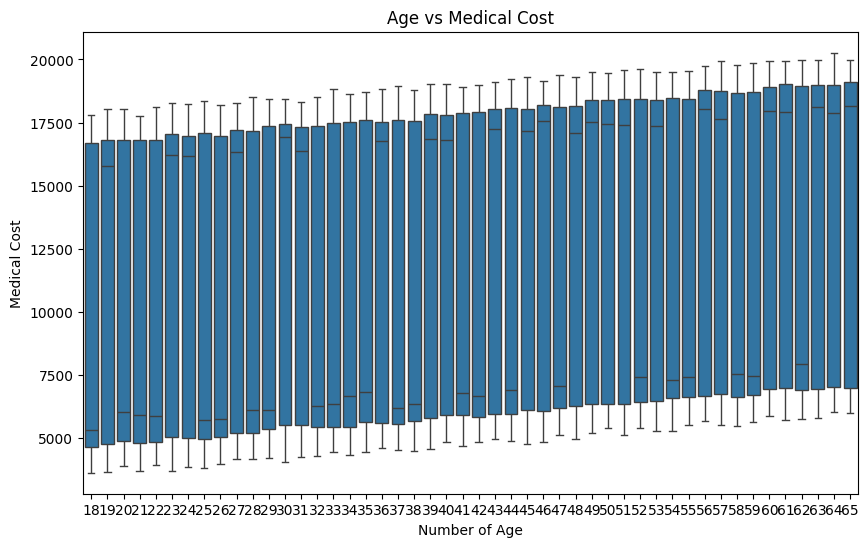

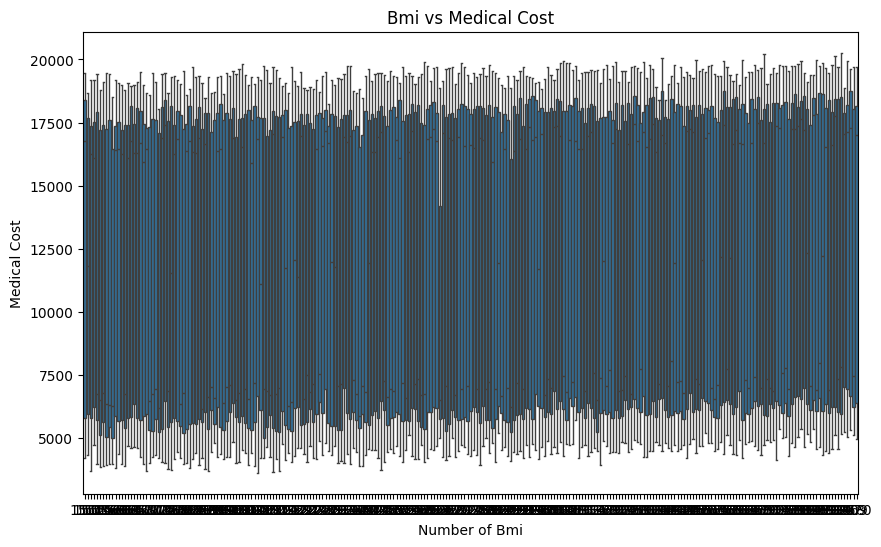

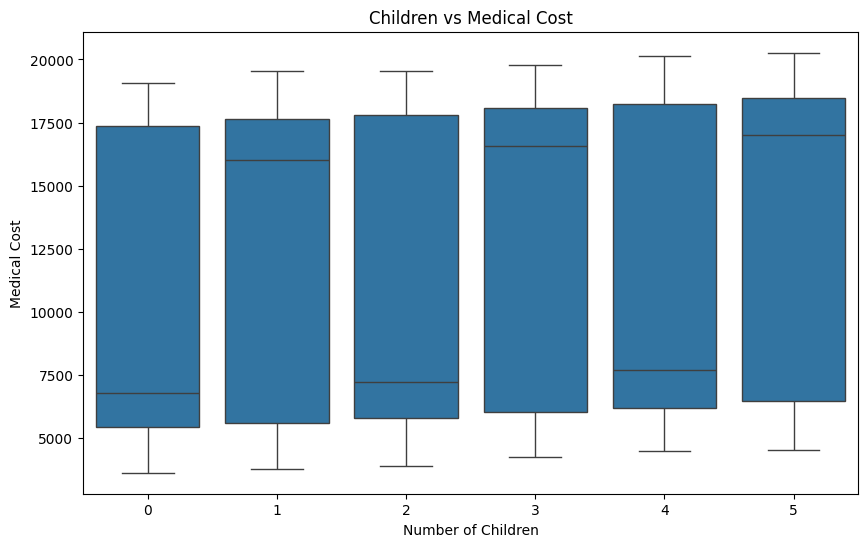

In [16]:
plotNumvsMedicalCost(dataset, num)


In [17]:
# Categorical vs Numerical[Medical Cost]
def plotCatvsMedicalCost(df, cat_feats):

    if len(cat_feats) == 0:
        return
    
    for col in cat_feats:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=col, y='Medical Cost', data=df)
        plt.title(f"{col} vs Medical Cost")
        plt.xlabel(f"{col}")
        plt.ylabel('Medical Cost')
        plt.show()

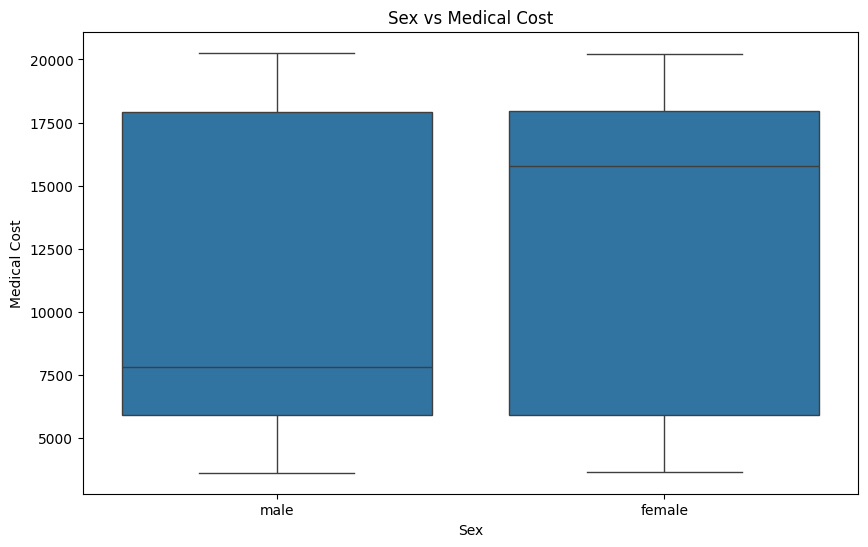

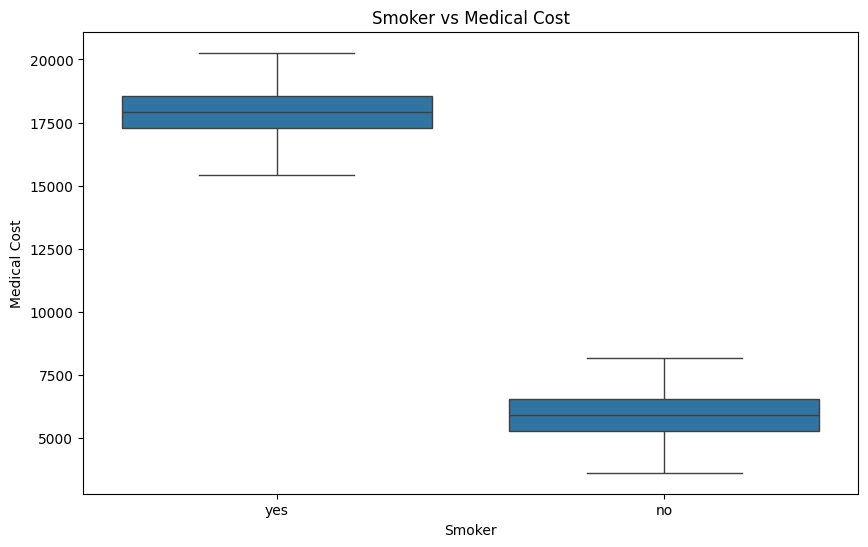

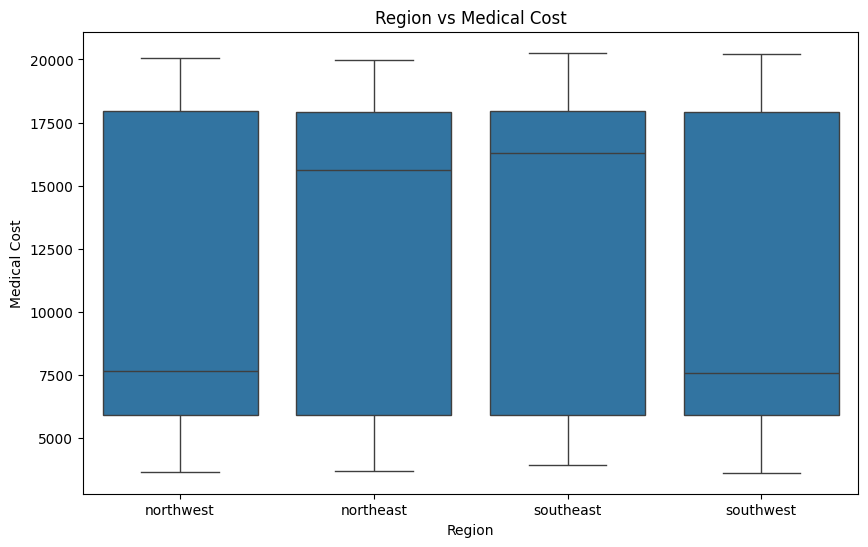

In [18]:
plotCatvsMedicalCost(dataset, cat)


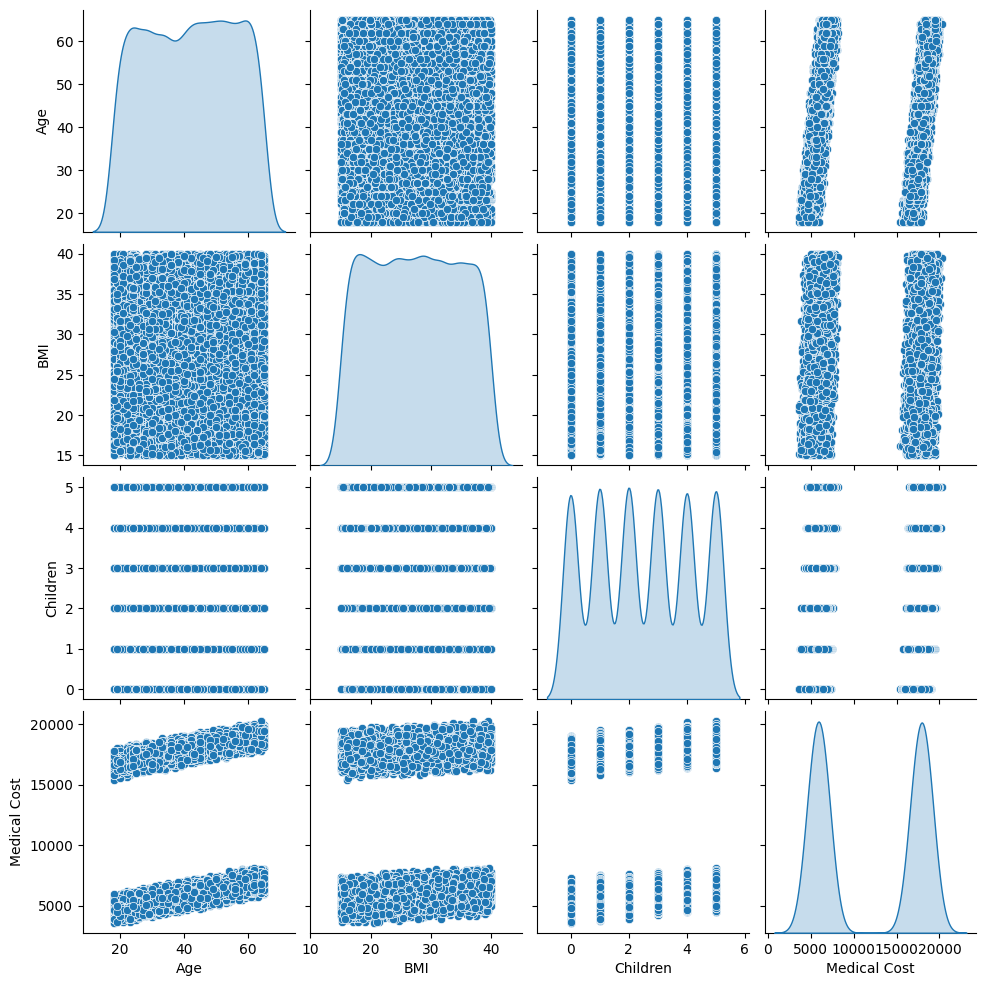

In [19]:
# Multivariate Analysis
# Pairplot for numerical features
sns.pairplot(data=dataset, vars=num, diag_kind='kde')
plt.show()

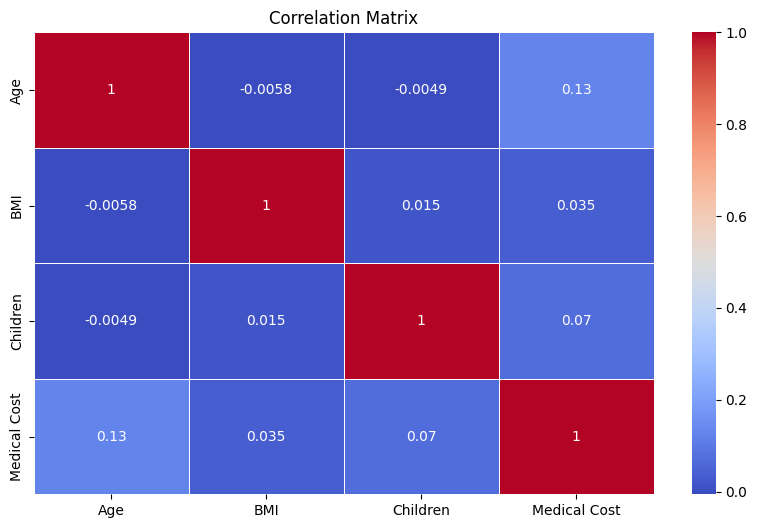

In [20]:
# Correlation matrix
plt.figure(figsize=(10, 6))
corr_matrix = dataset[num].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

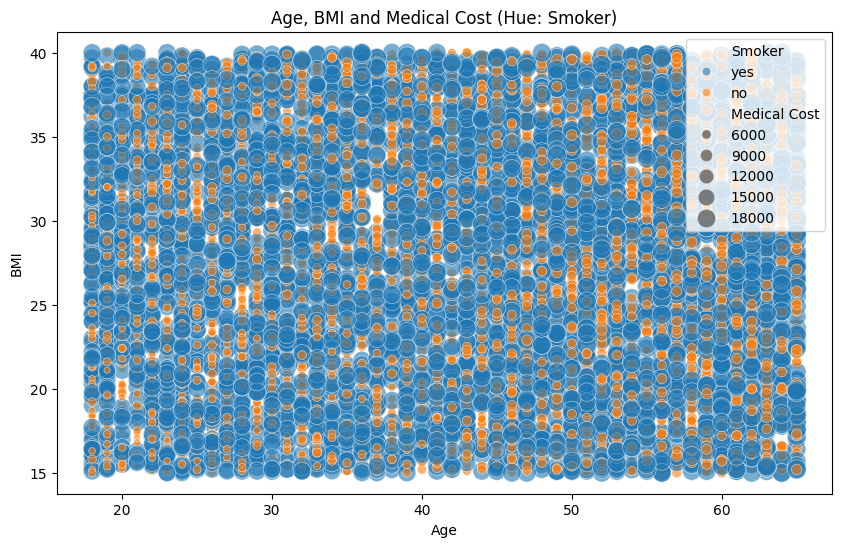

In [21]:
# Age, BMI, and Medical Cost with hue as Smoker
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='BMI', hue='Smoker', size='Medical Cost', sizes=(20, 200), data=dataset, alpha=0.6)
plt.title('Age, BMI and Medical Cost (Hue: Smoker)')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

Feature Engineering

In [22]:
# Feature Encoding
# One-Hot-Encode for catagorical variables

encoded_data = pd.get_dummies(data=dataset, columns=cat, drop_first=True)

encoded_data.head()

,Age,BMI,Children,Medical Cost,Sex_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest
0,58,15.6,2,17907.54,True,True,True,False,False
1,24,29.8,0,16312.64,True,True,False,False,False
2,50,29.0,5,6819.21,True,False,True,False,False
3,35,34.0,1,5247.87,True,False,False,True,False
4,31,17.6,3,17525.49,False,True,False,True,False


In [23]:
encoded_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               10000 non-null  int64  
 1   BMI               10000 non-null  float64
 2   Children          10000 non-null  int64  
 3   Medical Cost      10000 non-null  float64
 4   Sex_male          10000 non-null  bool   
 5   Smoker_yes        10000 non-null  bool   
 6   Region_northwest  10000 non-null  bool   
 7   Region_southeast  10000 non-null  bool   
 8   Region_southwest  10000 non-null  bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 361.5 KB


In [24]:
bool_cols = []

for col in encoded_data.columns:
    if encoded_data[col].dtypes == 'bool':
        bool_cols.append(col)

bool_cols

['Sex_male',
 'Smoker_yes',
 'Region_northwest',
 'Region_southeast',
 'Region_southwest']

In [25]:
encoded_data[bool_cols] = encoded_data[bool_cols].astype('int64')

encoded_data.tail()

,Age,BMI,Children,Medical Cost,Sex_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest
9995,24,26.9,2,16551.53,0,1,0,1,0
9996,49,33.4,3,6376.05,0,0,0,0,0
9997,52,38.1,5,18760.27,0,1,1,0,0
9998,24,33.4,4,5471.91,1,0,1,0,0
9999,24,21.7,5,4952.24,0,0,0,0,1


In [26]:
# Feature Scaling
# Standarize num values

SS = StandardScaler()

encoded_data[num] = SS.fit_transform(encoded_data[num])

encoded_data.head()

,Age,BMI,Children,Medical Cost,Sex_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest
0,1.182122,-1.632821,-0.294842,0.989304,1,1,1,0,0
1,-1.280391,0.331598,-1.470216,0.726707,1,1,0,0,0
2,0.602707,0.220927,1.468218,-0.836365,1,0,1,0,0
3,-0.483696,0.912624,-0.882529,-1.095082,1,0,0,1,0
4,-0.773403,-1.356143,0.292844,0.926400,0,1,0,1,0


In [27]:
# Feature Interaction

# Create interaction terms between 'age' and 'bmi'
encoded_data['age_bmi_interaction'] = encoded_data['Age'] * encoded_data['BMI']

# Create interaction terms between 'bmi' and 'children
encoded_data['bmi_children_interaction'] = encoded_data['BMI'] * encoded_data['Children']

encoded_data.head()

,Age,BMI,Children,Medical Cost,Sex_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest,age_bmi_interaction,bmi_children_interaction
0,1.182122,-1.632821,-0.294842,0.989304,1,1,1,0,0,-1.930194,0.481425
1,-1.280391,0.331598,-1.470216,0.726707,1,1,0,0,0,-0.424575,-0.487521
2,0.602707,0.220927,1.468218,-0.836365,1,0,1,0,0,0.133154,0.324368
3,-0.483696,0.912624,-0.882529,-1.095082,1,0,0,1,0,-0.441432,-0.805417
4,-0.773403,-1.356143,0.292844,0.926400,0,1,0,1,0,1.048845,-0.397139


In [28]:
# Polynomial Features
# Create polynomial features for 'bmi'

encoded_data['bmi_squaed'] = encoded_data['BMI'] ** 2
encoded_data['bmi_cubed'] = encoded_data['BMI'] ** 3

encoded_data.tail()

,Age,BMI,Children,Medical Cost,Sex_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest,age_bmi_interaction,bmi_children_interaction,bmi_squaed,bmi_cubed
9995,-1.280391,-0.069586,-0.294842,0.766040,0,1,0,1,0,0.089097,0.020517,0.004842,-0.000337
9996,0.530280,0.829620,0.292844,-0.909330,0,0,0,0,0,0.439931,0.242950,0.688269,0.571002
9997,0.747561,1.479815,1.468218,1.129704,0,1,1,0,0,1.106252,2.172691,2.189853,3.240578
9998,-1.280391,0.829620,0.880531,-1.058195,1,0,1,0,0,-1.062238,0.730506,0.688269,0.571002
9999,-1.280391,-0.788951,1.468218,-1.143757,0,0,0,0,1,1.010166,-1.158352,0.622444,-0.491078


In [29]:
# Log Transformation
# Apply log transformation to 'medical_cost' to reduce skewness
encoded_data['log_medical_cost'] = np.log(encoded_data['Medical Cost'] + 1)

encoded_data.head()

,Age,BMI,Children,Medical Cost,Sex_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest,age_bmi_interaction,bmi_children_interaction,bmi_squaed,bmi_cubed,log_medical_cost
0,1.182122,-1.632821,-0.294842,0.989304,1,1,1,0,0,-1.930194,0.481425,2.666105,-4.353274,0.687785
1,-1.280391,0.331598,-1.470216,0.726707,1,1,0,0,0,-0.424575,-0.487521,0.109957,0.036462,0.546216
2,0.602707,0.220927,1.468218,-0.836365,1,0,1,0,0,0.133154,0.324368,0.048809,0.010783,-1.810116
3,-0.483696,0.912624,-0.882529,-1.095082,1,0,0,1,0,-0.441432,-0.805417,0.832882,0.760108,NaN
4,-0.773403,-1.356143,0.292844,0.926400,0,1,0,1,0,1.048845,-0.397139,1.839123,-2.494112,0.655653


In [30]:
encoded_data.isnull().sum()


Age                            0
BMI                            0
Children                       0
Medical Cost                   0
Sex_male                       0
Smoker_yes                     0
Region_northwest               0
Region_southeast               0
Region_southwest               0
age_bmi_interaction            0
bmi_children_interaction       0
bmi_squaed                     0
bmi_cubed                      0
log_medical_cost            2315
dtype: int64

In [31]:
X = encoded_data.drop(columns=['Medical Cost', 'log_medical_cost'])
Y = encoded_data['Medical Cost']

print(f"The shape of the features   :   {X.shape}")
print(f"The shape of the labels    :   {Y.shape}")

The shape of the features   :   (10000, 12)
The shape of the labels    :   (10000,)


In [32]:
trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=42)

# Print statement to describe the split
print(f'Dataset has been split into training and testing sets.')
print(f'Training set size: {trainX.shape} ')
print(f'Testing set size: {testX.shape} ')
print(f'Training label size: {trainY.shape} ')
print(f'Testing label size: {testY.shape} ')

Dataset has been split into training and testing sets.
Training set size: (8000, 12) 
Testing set size: (2000, 12) 
Training label size: (8000,) 
Testing label size: (2000,) 


In [33]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Lasso Regression', Lasso()),
    ('Decision Tree', DecisionTreeRegressor()),
    ('Random Forest', RandomForestRegressor()),
    ('Support Vector Regressor', SVR()),
    ('XGBRegressor', XGBRegressor()),
    ('XGBRFRegressor', XGBRFRegressor())
]

In [34]:
def evalScores(Ytrue, Ypred):

    # Calculate the evaluation metrics
    mse = mean_squared_error(Ytrue, Ypred)
    mae = mean_absolute_error(Ytrue, Ypred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Ytrue, Ypred)

    # print evaluation metrics
    print('-' * 75)
    print(f'{name}:')
    print('-' * 75)
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'R^2: {r2}')
    print('-' * 75)

In [35]:
model_scores = []

# loop through the models and print scores
for name, model in models:

    # Fit the model
    model.fit(trainX, trainY)

    # Make Predictions
    predY = model.predict(testX)

    evalScores(testY, predY)

    # Calculate the evaluation metrics
    mse = mean_squared_error(testY, predY)
    mae = mean_absolute_error(testY, predY)
    rmse = np.sqrt(mse)
    r2 = r2_score(testY, predY)

    model_scores.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

---------------------------------------------------------------------------
Linear Regression:
---------------------------------------------------------------------------
MAE: 0.04166332436973357
MSE: 0.002303653584624868
RMSE: 0.047996391370861084
R^2: 0.9976882956238678
---------------------------------------------------------------------------
---------------------------------------------------------------------------
Ridge Regression:
---------------------------------------------------------------------------
MAE: 0.04166141997982315
MSE: 0.0023039660706695693
RMSE: 0.047999646568173494
R^2: 0.9976879820457492
---------------------------------------------------------------------------
---------------------------------------------------------------------------
Lasso Regression:
---------------------------------------------------------------------------
MAE: 0.9886562411279229
MSE: 0.9969303912290695
RMSE: 0.9984640159910969
R^2: -0.00041445618599889045
------------------------------

In [36]:
model_scores_df = pd.DataFrame(model_scores)

model_scores_df

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.002304,0.047996,0.041663,0.997688
1,Ridge Regression,0.002304,0.048000,0.041661,0.997688
2,Lasso Regression,0.996930,0.998464,0.988656,-0.000414
3,Decision Tree,0.005024,0.070879,0.057725,0.994959
4,Random Forest,0.002798,0.052894,0.044731,0.997192
5,Support Vector Regressor,0.003794,0.061597,0.049355,0.996193
6,XGBRegressor,0.002715,0.052109,0.044155,0.997275
7,XGBRFRegressor,0.002938,0.054201,0.045515,0.997052


In [37]:
def fineTuneModel(trainX, testX, trainY, testY, model_name, model_algo, params, cv=5):
    """
    Fit and evaluate a machine learning model using GridSearchCV for hyperparameter tuning.

    Parameters:
    - trainX: Training features
    - testX: Testing features
    - trainY: Training target
    - testY: Testing target
    - model_name: Name of the model for reference
    - model_algo: The model algorithm (e.g., LinearRegression(), RandomForestRegressor())
    - params: Parameter grid for hyperparameter tuning
    - cv: Number of cross-validation folds (default: 5)

    Returns:
    - None: Prints the evaluation results and appends scores to the model_scores list
    """
    np.random.seed(10)

    print(f"-"*75)
    print(f"\nStarting hyperparameter tuning for {model_name}...")
    print(f"-"*75)

    grid = GridSearchCV(
        estimator=model_algo,
        param_grid=params,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        scoring='neg_mean_squared_error'
    )

    # Fit model
    res = grid.fit(trainX, trainY)
    
    best_params = res.best_params_
    best_scores = res.best_score_

    print(f"Best parameters for {model_name}: {best_params}")
    print(f"Best cross-validation score: {best_scores}")

    # Predictions
    predY = grid.predict(testX)

    # Calculate the evaluation metrics
    mse = mean_squared_error(testY, predY)
    mae = mean_absolute_error(testY, predY)
    rmse = np.sqrt(mse)
    r2 = r2_score(testY, predY)

    print(f"Evaluation metrics for {model_name}:")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"R-squared (R2): {r2}")

    # Append scores to the global model_scores list
    model_scores.append({
        'Model': model_name + 'Tuned',
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    print(f"Finished hyperparameter tuning for {model_name}.\n")
    print(f"-"*75)

In [38]:
# Define models and their parameter grids
models = {
    'LinearRegression': {
        'model': LinearRegression(),
        'param_grid': {}  # LinearRegression has no hyperparameters to tune
    },
    'RidgeRegression': {
        'model': Ridge(),
        'param_grid': {
            'alpha': [0.1, 1, 10, 100]
        }
    },
    'LassoRegression': {
        'model': Lasso(),
        'param_grid': {
            'alpha': [0.1, 1, 10, 100]
        }
    },
    'DecisionTreeRegressor': {
        'model': DecisionTreeRegressor(),
        'param_grid': {
            'max_depth': [10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        }
    },
    'RandomForestRegressor': {
        'model': RandomForestRegressor(),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        }
    },
    'SVR': {
        'model': SVR(),
        'param_grid': {
            'C': [0.1, 1, 10, 100],
            'epsilon': [0.01, 0.1, 0.2],
        }
    },
    'XGBRegressor': {
        'model': XGBRegressor(),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 10],
            'subsample': [0.8, 0.9, 1.0]
        }
    },
    'XGBRFRegressor': {
        'model': XGBRFRegressor(),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 10],
            'subsample': [0.8, 0.9, 1.0]
        }
    }
}

In [39]:
# Loop through models and perform hyperparameter tuning and evaluation
for model_name, model_details in models.items():
    model_algo = model_details['model']
    params = model_details['param_grid']

    print("-"*75)
    print(f"Training and tuning model   :   {model_name}")
    print("-"*75)

    fineTuneModel(trainX, testX, trainY, testY,
               model_name, model_algo,
               params, cv=5)

---------------------------------------------------------------------------
Training and tuning model   :   LinearRegression
---------------------------------------------------------------------------
---------------------------------------------------------------------------

Starting hyperparameter tuning for LinearRegression...
---------------------------------------------------------------------------
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters for LinearRegression: {}
Best cross-validation score: -0.0022804798131748393
Evaluation metrics for LinearRegression:
Mean Squared Error (MSE): 0.002303653584624868
Root Mean Squared Error (RMSE): 0.047996391370861084
Mean Absolute Error (MAE): 0.04166332436973357
R-squared (R2): 0.9976882956238678
Finished hyperparameter tuning for LinearRegression.

---------------------------------------------------------------------------
---------------------------------------------------------------------------
Training a

In [40]:
model_scores_df = pd.DataFrame(model_scores)

model_scores_df

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.002304,0.047996,0.041663,0.997688
1,Ridge Regression,0.002304,0.048000,0.041661,0.997688
2,Lasso Regression,0.996930,0.998464,0.988656,-0.000414
3,Decision Tree,0.005024,0.070879,0.057725,0.994959
4,Random Forest,0.002798,0.052894,0.044731,0.997192
5,Support Vector Regressor,0.003794,0.061597,0.049355,0.996193
6,XGBRegressor,0.002715,0.052109,0.044155,0.997275
7,XGBRFRegressor,0.002938,0.054201,0.045515,0.997052
8,LinearRegressionTuned,0.002304,0.047996,0.041663,0.997688
9,RidgeRegressionTuned,0.002304,0.047996,0.041663,0.997688


In [41]:
def buildNeuralNetwork(input_shape):
    np.random.seed(10)
    tf.random.set_seed(10)  # Set seed for TensorFlow to ensure reproducibility

    model = Sequential([
        Dense(128, input_shape=input_shape, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(1, activation='linear')
    ])

    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    model.summary()

    return model

In [42]:
input_shape = (trainX.shape[1], )

model = buildNeuralNetwork(input_shape=input_shape)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,385 (314.00 KB)

 Trainable params: 79,169 (309.25 KB)

 Non-trainable params: 1,216 (4.75 KB)

In [43]:
# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [44]:
history = model.fit(trainX, trainY,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=32,
                    # callbacks=[early_stopping]
                )

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 2.9538 - mae: 1.3571 - val_loss: 0.9263 - val_mae: 0.9117
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.5165 - mae: 1.0007 - val_loss: 0.5236 - val_mae: 0.6795
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9177 - mae: 0.7936 - val_loss: 0.2476 - val_mae: 0.4376
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5881 - mae: 0.6347 - val_loss: 0.0919 - val_mae: 0.2343
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4141 - mae: 0.5242 - val_loss: 0.0357 - val_mae: 0.1326
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3139 - mae: 0.4479 - val_loss: 0.0243 - val_mae: 0.1183
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2531 - mae: 0.4043 - val_loss: 0.0154 - val_mae: 0.0955
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2237 - mae: 0.3739 - val_loss: 0.0206 - val_mae: 0.1153
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms

In [45]:
test_loss, test_mae = model.evaluate(testX, testY)

print(f'Test Loss: {test_loss}')
print(f'Test MAE: {test_mae}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0069 - mae: 0.0675 
Test Loss: 0.006902588997036219
Test MAE: 0.06752906739711761


In [46]:
predY = model.predict(testX)


# Calculate the evaluation metrics
mse = mean_squared_error(testY, predY)
mae = mean_absolute_error(testY, predY)
rmse = np.sqrt(mse)
r2 = r2_score(testY, predY)

# print evaluation metrics
print('-' * 75)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2: {r2}')
print('-' * 75)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
---------------------------------------------------------------------------
MAE: 0.06752908280138527
MSE: 0.0069025895697333375
RMSE: 0.08308182454504316
R^2: 0.9930732873112971
---------------------------------------------------------------------------


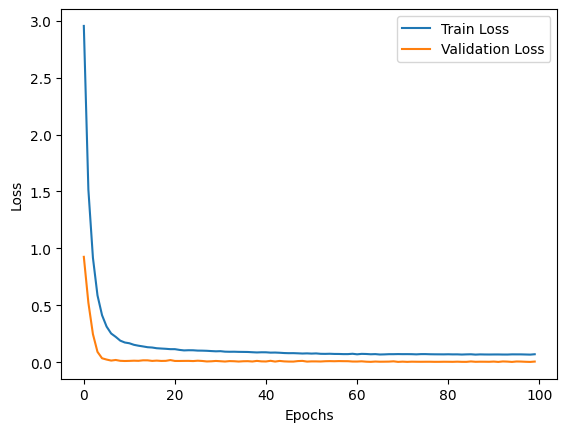

In [47]:
# Plotting the loss over epochs
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

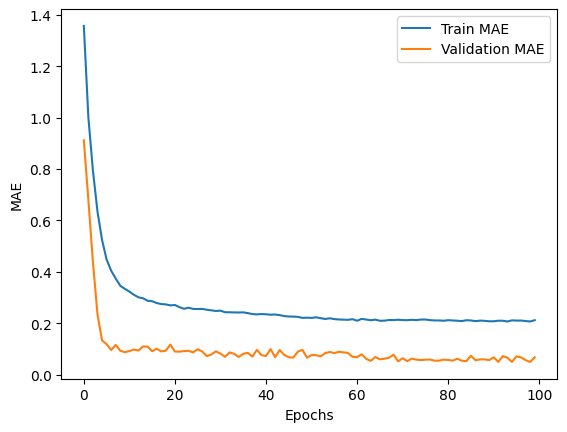

In [48]:
# Plotting the learning curves (Mean Absolute Error over epochs)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()